In [1]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

gc = gspread.authorize(creds)
import pandas as pd

import re

def extract_max_score(nds_string):
    """Extracts the maximum number from a string like '32(40)' or '27'."""
    if isinstance(nds_string, str):
        numbers = re.findall(r'\d+', nds_string)
        if numbers:
            # Convert extracted strings to integers and find the maximum
            return max(map(int, numbers))
    return None # Return None for invalid or empty strings

In [2]:
import pandas as pd
spreadsheet_name = 'MASTER_SPREADSHEET'
sheet_names = ['Filtered_Subset_No_REBOA', 'No_REBOA_selected_column','cleaned_no_reboa']

# Assuming 'gc' is a valid gspread client object already initialized
# If not, you would need to add code to authenticate and initialize it.
# For the purpose of fixing the header issue, I'll assume gc is available.

spreadsheet = gc.open(spreadsheet_name)
dfs = {}
for sheet_name in sheet_names:
    try:
        worksheet = spreadsheet.worksheet(sheet_name)
        # Get all values from the sheet
        all_values = worksheet.get_all_values()

        if not all_values:
            print(f"Warning: Sheet '{sheet_name}' is empty.")
            continue

        # Assuming the first row is the header
        headers = all_values[0]
        data = all_values[1:]

        # Create a DataFrame
        dfs[sheet_name] = pd.DataFrame(data, columns=headers)

        print(f"Successfully loaded sheet: {sheet_name}")
        display(dfs[sheet_name].head())
    except gspread.WorksheetNotFound:
        print(f"Sheet '{sheet_name}' not found in the spreadsheet.")
    except Exception as e:
        print(f"An error occurred while loading sheet '{sheet_name}': {e}")

Successfully loaded sheet: Filtered_Subset_No_REBOA


,Rat ID,Last Edited By:,"Acute Imaging (AI), Chronic Imaging (CI), Microelectrode (M), KCl, DC, Weiss (W), Sham (S)",Intended Asphyxia/Asystole time (min),"Fasted (1 yes, 0 no)",ROSC or Dead,Vendor,Strain/Sex,Date of Implantation,Date died,...,MAP6,HR6,SBP7,DBP7,PP7,MAP7,HR7,Tail Blood Glucose Pre-Intubation,Tail Blood Glucose Post-Intubation,Tail Blood Glucose Baseline
0,021115MH1,"DB, JA",,7,1,ROSC,,Wistar/M,2/11/2015,,...,,,,,,,,,,
1,021815JK,"DB, JA",,7.5,1,ROSC,,Wistar/M,2/18/2015,,...,,,,,,,,,,
2,030415MH,"AO, JA",,8,1,ROSC,,Wistar/M,3/4/2015,,...,,,,,,,,,,
3,030615AB2,"AO, JA",,8,1,ROSC,,Wistar/M,3/6/2015,,...,,,,,,,,,,
4,033115AB,"DH, JA",,8,1,ROSC,,Wistar/M,3/31/2015,,...,,,,,,,,,,


Successfully loaded sheet: No_REBOA_selected_column


,Rat ID,Intended Asphyxia/Asystole time (min),Time from ROSC that BSR Reaches 0.5,"Fasted (1 yes, 0 no)",CA Weight (g),postCAinout_revise,extraEPI,extraBI,extra saline flush (for Epi and Bi only),pH,...,MAP at the time of MinDBP,DBP_baseline,DBP start (Asphyxia/KCl),DBP EEGflat,DBP for MaxSBP,DBP for MinSBP,MaxDBP (postROSC),MinDBP (postROSC),DBP5minpostROSC,DBP30minpostROSC
0,021115MH1,7,22.85,1,335,4.25,0.2,0.5,0.5,7.299,...,40.67,67.38688863,66,46,111,30,111,29,42,69
1,021815JK,7.5,20.55,1,352,6.8,0.3,0,0.5,7.247,...,50.00,77.42325516,79,34,113,36,115,36,85,74
2,030415MH,8,22,1,373,6,0,0,0,7.345,...,53.67,91.89491247,77,24,126,39,132,39,55,82
3,030615AB2,8,16.2,1,294,4.2,0,0,0,7.339,...,52.33,88.72612228,89,36,125,35,125,34,97,88
4,033115AB,8,23,1,290,4.8,0,0,0,7.493,...,49.67,66.5985054,69,25,117,33,121,33,59,59


Successfully loaded sheet: cleaned_no_reboa


,Rat ID,Intended Asphyxia/Asystole time (min),"Fasted (1 yes, 0 no)",CA Weight (g),postCAin,postCAout,postCAinout_revise,extraEPI,extraBI,extra saline flush (for Epi and Bi only),...,MAP at the time of MinDBP,DBP_baseline,DBP start (Asphyxia/KCl),DBP EEGflat,DBP for MaxSBP,DBP for MinSBP,MaxDBP (postROSC),MinDBP (postROSC),DBP5minpostROSC,DBP30minpostROSC
0,021115MH1,7,1,335,4.25,0,4.25,0.2,0.5,0.5,...,0.5078971065,67.38688863,0.9794190137,0.6826253732,1.647204705,0.4451904608,1.647204705,0.4303507788,0.6232666451,1.02393806
1,021815JK,7.5,1,352,6.8,0,6.8,0.3,0,0.5,...,0.5335838319,77.42325516,1.020365262,0.439144543,1.459509805,0.4649765749,1.485341836,0.4649765749,1.097861357,0.9557851817
2,030415MH,8,1,373,6,0,6,0,0,0,...,0.4647506102,91.89491247,0.8379136335,0.2611678858,1.3711314,0.4243978143,1.436423372,0.4243978143,0.5985097382,0.8923236097
3,030615AB2,8,1,294,4.2,0,4.2,0,0,0,...,0.4690547235,88.72612228,1.003086777,0.4057429658,1.408829742,0.3944723279,1.408829742,0.3832016899,1.09325188,0.9918161386
4,033115AB,8,1,290,4.8,0,4.8,0,0,0,...,0.5532892566,66.5985054,1.036059287,0.3753837995,1.756796182,0.4955066154,1.81685759,0.4955066154,0.8859057669,0.8859057669


In [3]:
if 'Filtered_Subset_No_REBOA' in dfs and '4hr NDS' in dfs['Filtered_Subset_No_REBOA'].columns:
    nds_4hr = dfs['Filtered_Subset_No_REBOA']['4hr NDS']
    print("Successfully extracted '4hr NDS' column:")
    display(nds_4hr.head())
else:
    print("Could not extract '4hr NDS'. Either the 'Filtered_Subset_No_REBOA' dataframe or the '4 hr NDS' column was not found.")


# Apply the function to the '4 hr NDS' column
if 'nds_4hr' in locals():
    max_4hr_nds_scores = nds_4hr.apply(extract_max_score)
    print("Extracted maximum scores from '4 hr NDS' column:")
    display(max_4hr_nds_scores.head())
else:
    print("The 'nds_4hr' variable was not found. Please make sure the '4 hr NDS' column was extracted successfully.")

if 'Filtered_Subset_No_REBOA' in dfs and '24hr NDS' in dfs['Filtered_Subset_No_REBOA'].columns:
    nds_24hr = dfs['Filtered_Subset_No_REBOA']['24hr NDS']
    print("Successfully extracted '24hr NDS' column:")
    display(nds_24hr.head())
else:
    print("Could not extract '24hr NDS'. Either the 'Filtered_Subset_No_REBOA' dataframe or the '24hr NDS' column was not found.")

# Apply the function to the '24 hr NDS' column
if 'nds_24hr' in locals():
    max_nds_24hr_scores = nds_24hr.apply(extract_max_score)
    # Fill NaN entries with 60
    max_nds_24hr_scores = max_nds_24hr_scores.fillna(60)
    print("Extracted maximum scores from '24 hr NDS' column and filled NaN with 60:")
    display(max_nds_24hr_scores.head())
else:
    print("The 'nds_24hr' variable was not found. Please make sure the '24 hr NDS' column was extracted successfully.")

# Extract and process '24morning NDS'
if 'Filtered_Subset_No_REBOA' in dfs and '24morning NDS' in dfs['Filtered_Subset_No_REBOA'].columns:
    nds_24morning = dfs['Filtered_Subset_No_REBOA']['24morning NDS']
    print("Successfully extracted '24morning NDS' column:")
    display(nds_24morning.head())

    # Apply the function to the '24morning NDS' column
    max_nds_24morning_scores = nds_24morning.apply(extract_max_score)
    print("Extracted maximum scores from '24morning NDS' column:")
    display(max_nds_24morning_scores.head())
else:
    print("Could not extract '24morning NDS'. Either the 'Filtered_Subset_No_REBOA' dataframe or the '24morning NDS' column was not found.")

Successfully extracted '4hr NDS' column:


,4hr NDS
0,32(40)
1,33(29)
2,26 (25)
3,39 (41)
4,27


Extracted maximum scores from '4 hr NDS' column:


,4hr NDS
0,40
1,33
2,26
3,41
4,27


Successfully extracted '24hr NDS' column:


...

,24hr NDS
0,74
1,59
2,53
3,69
4,70


Successfully extracted '24morning NDS' column:


,24morning NDS
0,-
1,-
2,-
3,-
4,-


Extracted maximum scores from '24morning NDS' column:


,24morning NDS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN


In [4]:
# Ensure both series have the same index for comparison
max_nds_24hr_scores = max_nds_24hr_scores.reindex(max_nds_24morning_scores.index)

# Create a boolean mask where 24morning NDS is greater than 24hr NDS
# Use .fillna(0) or another appropriate value for comparison with NaNs if needed,
# or handle NaNs explicitly. Assuming NaNs in 24morning should not trigger replacement.
# If a value is NaN in max_nds_24morning_scores, the comparison will result in False.
mask = (max_nds_24morning_scores > max_nds_24hr_scores)

# Replace values in max_nds_24hr_scores where the mask is True
max_nds_24hr_scores = max_nds_24hr_scores.where(~mask, max_nds_24morning_scores)

print("Updated max_nds_24hr_scores based on 24morning NDS:")
display(max_nds_24hr_scores.head())

Updated max_nds_24hr_scores based on 24morning NDS:


/tmp/ipykernel_27137/4263197844.py:11: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  max_nds_24hr_scores = max_nds_24hr_scores.where(~mask, max_nds_24morning_scores)


,24hr NDS
0,74
1,59
2,53
3,69
4,70


In [5]:
import numpy as np

def classify_by_percentile(arr, percentile_threshold=50):
    """
    Classifies values in an array as 'good' or 'bad' based on a given percentile.

    Args:
        arr (array-like): The input array of numerical values.
        percentile_threshold (int or float): The percentile to use as the threshold (between 0 and 100).

    Returns:
        numpy.ndarray: An array of strings ('good' or 'bad') corresponding to the input values.
    """
    # Convert the input to a numpy array
    arr = np.array(arr)

    # Calculate the specified percentile
    percentile_value = np.percentile(arr, percentile_threshold)

    # Classify values based on the percentile
    classification = np.where(arr > percentile_value, 'good', 'bad')

    return classification

In [6]:
import numpy as np

# Calculate the 50th percentile of the 4hr NDS scores
percentile_50_4hr_nds = np.percentile(max_4hr_nds_scores, 50)
percentile_50_24hr_nds = np.percentile(max_nds_24hr_scores, 60)

print(f"The 50th percentile for 4hr NDS scores is: {percentile_50_4hr_nds}")
print(f"The 50th percentile for 24hr NDS scores is: {percentile_50_24hr_nds}")

The 50th percentile for 4hr NDS scores is: 35.0
The 50th percentile for 24hr NDS scores is: 75.0


In [7]:
# Apply the classify_by_percentile function to max_4hr_nds_scores
classification_4hr_nds = classify_by_percentile(max_4hr_nds_scores,50)
classification_24hr_nds = classify_by_percentile(max_nds_24hr_scores,60)


In [8]:
def verify_classification(df, score_series, classification_array, group_col='Intended Asphyxia/Asystole time (min)', percentile_threshold=50):
    """
    Creates a verification DataFrame with NDS score, Group Percentile, and Classification.
    """
    # Handle potential duplicate columns for the grouping variable
    group_data = df[group_col]
    if isinstance(group_data, pd.DataFrame):
        group_data = group_data.iloc[:, 0]

    # Create base DataFrame
    verify_df = pd.DataFrame({
        'Group': group_data.values,
        'NDS Score': score_series.values,
        'Classification': classification_array
    })

    # Calculate percentiles for each group to add as a column
    unique_groups = verify_df['Group'].unique()
    group_percentiles = {}

    for group in unique_groups:
        if pd.isna(group):
            group_indices = verify_df['Group'].isna()
        else:
            group_indices = verify_df['Group'] == group

        # Get scores for this group
        group_scores = verify_df.loc[group_indices, 'NDS Score']
        valid_scores = group_scores.dropna()

        if not valid_scores.empty:
            threshold = np.percentile(valid_scores, percentile_threshold)
            group_percentiles[group] = threshold
        else:
            group_percentiles[group] = np.nan

    # Map the calculated percentiles back to the DataFrame
    verify_df['Group 50th Percentile'] = verify_df['Group'].map(group_percentiles)

    # Reorder columns as requested: 1. nds score 2. 50 percentile 3. classification
    final_df = verify_df[['NDS Score', 'Group 50th Percentile', 'Classification', 'Group']]

    return final_df

# Run verification for 4hr NDS
if 'Filtered_Subset_No_REBOA' in dfs and 'classification_4hr_nds_grouped' in locals():
    df_subset = dfs['Filtered_Subset_No_REBOA']

    verification_df_4hr = verify_classification(
        df_subset,
        max_4hr_nds_scores,
        classification_4hr_nds_grouped
    )

    print("Verification DataFrame (First 20 rows):")
    display(verification_df_4hr.head(20))

    # Optional: Check if logic holds (Score > Percentile should be 'good')
    # Note: NaN scores are classified as 'bad' by default in the previous function
    verification_df_4hr['Logic Check'] = verification_df_4hr.apply(
        lambda row: 'Correct' if (
            (row['Classification'] == 'good' and row['NDS Score'] > row['Group 50th Percentile']) or
            (row['Classification'] == 'bad' and (pd.isna(row['NDS Score']) or row['NDS Score'] <= row['Group 50th Percentile']))
        ) else 'Mismatch', axis=1
    )
    print("\nLogic Check Counts:")
    print(verification_df_4hr['Logic Check'].value_counts())
else:
    print("Required variables not found.")

Required variables not found.


In [9]:
import numpy as np
import pandas as pd

def classify_by_group_percentile(df, score_series, group_col='Intended Asphyxia/Asystole time (min)', percentile_threshold=50):
    """
    Classifies values in a score series as 'good' or 'bad' based on a percentile
    calculated within groups defined by a column in the dataframe.

    Args:
        df (pd.DataFrame): The dataframe containing the grouping column.
        score_series (pd.Series or array-like): The scores to classify. Must be aligned with df.
        group_col (str): The column name to group by.
        percentile_threshold (int or float): The percentile to use as the threshold (0-100).

    Returns:
        np.ndarray: An array of strings ('good' or 'bad') corresponding to the input scores.
    """
    # Ensure inputs are aligned/same length
    if len(df) != len(score_series):
        raise ValueError("Dataframe and score series must have the same length.")

    # Handle potential duplicate columns for the grouping variable
    group_data = df[group_col]
    if isinstance(group_data, pd.DataFrame):
        print(f"Warning: Multiple columns found with name '{group_col}'. Using the first one.")
        group_data = group_data.iloc[:, 0]

    # Create a temporary dataframe to handle the grouping and alignment
    # Using .values ensures we align by position, as requested ("same order")
    temp_df = pd.DataFrame({
        group_col: group_data.values,
        'score': score_series.values
    })

    # Initialize classification column with object dtype to avoid FutureWarning when assigning strings
    temp_df['classification'] = np.nan
    temp_df['classification'] = temp_df['classification'].astype(object)

    # Group by the specified column
    unique_groups = temp_df[group_col].unique()

    for group in unique_groups:
        # Get indices for this group
        if pd.isna(group):
            group_indices = temp_df[group_col].isna()
        else:
            group_indices = temp_df[group_col] == group

        group_scores = temp_df.loc[group_indices, 'score']

        # Drop NaNs for percentile calculation
        valid_scores = group_scores.dropna()

        if not valid_scores.empty:
            # Calculate the threshold for this specific group
            threshold = np.percentile(valid_scores, percentile_threshold)

            # Classify: > threshold is 'good', else 'bad'
            temp_df.loc[group_indices, 'classification'] = np.where(group_scores > threshold, 'good', 'bad')
        else:
             temp_df.loc[group_indices, 'classification'] = 'bad'

    return temp_df['classification'].values

# Apply the new function
if 'Filtered_Subset_No_REBOA' in dfs:
    df_subset = dfs['Filtered_Subset_No_REBOA']

    # Classify 4hr NDS
    classification_4hr_nds_grouped = classify_by_group_percentile(
        df_subset,
        max_4hr_nds_scores,
        group_col='Intended Asphyxia/Asystole time (min)',
        percentile_threshold=50
    )

    # Classify 24hr NDS
    classification_24hr_nds_grouped = classify_by_group_percentile(
        df_subset,
        max_nds_24hr_scores,
        group_col='Intended Asphyxia/Asystole time (min)',
        percentile_threshold=50 # Using 50 as requested
    )

    print("Classification based on group percentiles complete.")
    print("Sample of 4hr grouped classification:", classification_4hr_nds_grouped[:10])
    print("Sample of 24hr grouped classification:", classification_24hr_nds_grouped[:10])
else:
    print("Dataframe 'Filtered_Subset_No_REBOA' not found.")

Classification based on group percentiles complete.
Sample of 4hr grouped classification: ['bad' 'good' 'bad' 'good' 'bad' 'bad' 'bad' 'good' 'bad' 'bad']
Sample of 24hr grouped classification: ['bad' 'bad' 'bad' 'bad' 'good' 'bad' 'bad' 'bad' 'bad' 'bad']


In [10]:
df_no_reboa=dfs['No_REBOA_selected_column'].copy()

# Define the columns to normalize and the baseline column
dbp_columns_to_normalize = [
    'DBP start (Asphyxia/KCl)',
    'DBP EEGflat',
    'MaxDBP (postROSC)',
    'MinDBP (postROSC)',
    'DBP5minpostROSC',
    'DBP30minpostROSC',
    'DBP for MaxSBP',
    'DBP for MinSBP'
]

baseline_dbp_column = 'DBP_baseline'

# Ensure baseline column exists
if baseline_dbp_column not in df_no_reboa.columns:
    print(f"Error: Baseline column '{baseline_dbp_column}' not found in the DataFrame.")
else:
    # Convert relevant columns to numeric, coercing errors
    for col in dbp_columns_to_normalize + [baseline_dbp_column]:
        df_no_reboa[col] = pd.to_numeric(df_no_reboa[col], errors='coerce')

    # Fill potential NaNs in baseline with a non-zero value (e.g., mean or median) or handle them as appropriate for normalization
    # For simplicity, let's fill NaNs in the baseline with the mean of the column, only if there are NaNs
    if df_no_reboa[baseline_dbp_column].isnull().any():
        mean_baseline = df_no_reboa[baseline_dbp_column].mean()
        df_no_reboa[baseline_dbp_column].fillna(mean_baseline, inplace=True)
        print(f"Filled NaN values in '{baseline_dbp_column}' with the mean ({mean_baseline:.2f}).")


    # Perform the normalization and replace original columns
    for col in dbp_columns_to_normalize:
        # Avoid division by zero: if baseline is 0, the normalized value will be NaN
        df_no_reboa[col] = df_no_reboa[col] / df_no_reboa[baseline_dbp_column]

    print("Normalization and replacement complete. Displaying head of the DataFrame with normalized DBP columns:")
    display(df_no_reboa[[baseline_dbp_column] + dbp_columns_to_normalize].head())

# Define the columns to normalize and the baseline column
sbp_columns_to_normalize = [
    'SBP start (Asphyxia/KCl)',
    'SBP EEGflat',
    'MaxSBP (postROSC)',
    'MinSBP (postROSC)',
    'SBP for Min DBP',
    'SBP for Max DBP',
    'SBP5minpostROSC',
    'SBP30minpostROSC'
]

baseline_sbp_column = 'SBP_baseline'

# Ensure baseline column exists
if baseline_sbp_column not in df_no_reboa.columns:
    print(f"Error: Baseline column '{baseline_sbp_column}' not found in the DataFrame.")
else:
    # Convert relevant columns to numeric, coercing errors
    for col in sbp_columns_to_normalize + [baseline_sbp_column]:
        df_no_reboa[col] = pd.to_numeric(df_no_reboa[col], errors='coerce')

    # Fill potential NaNs in baseline with a non-zero value (e.g., mean or median) or handle them as appropriate for normalization
    # For simplicity, let's fill NaNs in the baseline with the mean of the column, only if there are NaNs
    if df_no_reboa[baseline_sbp_column].isnull().any():
        mean_baseline = df_no_reboa[baseline_sbp_column].mean()
        df_no_reboa[baseline_sbp_column].fillna(mean_baseline, inplace=True)
        print(f"Filled NaN values in '{baseline_sbp_column}' with the mean ({mean_baseline:.2f}).")


    # Perform the normalization and replace original columns
    for col in sbp_columns_to_normalize:
        # Avoid division by zero: if baseline is 0, the normalized value will be NaN
        df_no_reboa[col] = df_no_reboa[col] / df_no_reboa[baseline_sbp_column]

    print("Normalization and replacement complete. Displaying head of the DataFrame with normalized columns:")
    display(df_no_reboa[[baseline_sbp_column] + sbp_columns_to_normalize].head())


# Define the columns to normalize and the baseline column
map_columns_to_normalize = [
    'MAP start (Asphyxia/KCl, whole integer)',
    'MAP EEG flat',
    'MAP EEG Flat Formula',
    'MAP for MaxSBP',
    'MAP at the time of MinSBP',
    'MAP at the time of MaxDBP',
    'MAP at the time of MinDBP'
]

baseline_map_column = 'MAP_baseline'

# Ensure baseline column exists
if baseline_map_column not in df_no_reboa.columns:
    print(f"Error: Baseline column '{baseline_map_column}' not found in the DataFrame.")
else:
    # Convert relevant columns to numeric, coercing errors
    for col in map_columns_to_normalize + [baseline_map_column]:
        df_no_reboa[col] = pd.to_numeric(df_no_reboa[col], errors='coerce')

    # Fill potential NaNs in baseline with a non-zero value (e.g., mean or median) or handle them as appropriate for normalization
    # For simplicity, let's fill NaNs in the baseline with the mean of the column, only if there are NaNs
    if df_no_reboa[baseline_map_column].isnull().any():
        mean_baseline = df_no_reboa[baseline_map_column].mean()
        df_no_reboa[baseline_map_column].fillna(mean_baseline, inplace=True)
        print(f"Filled NaN values in '{baseline_map_column}' with the mean ({mean_baseline:.2f}).")


    # Perform the normalization and replace original columns
    for col in map_columns_to_normalize:
        # Avoid division by zero: if baseline is 0, the normalized value will be NaN
        df_no_reboa[col] = df_no_reboa[col] / df_no_reboa[baseline_map_column]

    print("Normalization and replacement complete. Displaying head of the DataFrame with normalized MAP columns:")
    display(df_no_reboa[[baseline_map_column] + map_columns_to_normalize].head())

Normalization and replacement complete. Displaying head of the DataFrame with normalized DBP columns:


,DBP_baseline,DBP start (Asphyxia/KCl),DBP EEGflat,MaxDBP (postROSC),MinDBP (postROSC),DBP5minpostROSC,DBP30minpostROSC,DBP for MaxSBP,DBP for MinSBP
0,67.386889,0.979419,0.682625,1.647205,0.430351,0.623267,1.023938,1.647205,0.445190
1,77.423255,1.020365,0.439145,1.485342,0.464977,1.097861,0.955785,1.459510,0.464977
2,91.894912,0.837914,0.261168,1.436423,0.424398,0.598510,0.892324,1.371131,0.424398
3,88.726122,1.003087,0.405743,1.408830,0.383202,1.093252,0.991816,1.408830,0.394472
4,66.598505,1.036059,0.375384,1.816858,0.495507,0.885906,0.885906,1.756796,0.495507


Normalization and replacement complete. Displaying head of the DataFrame with normalized columns:


,SBP_baseline,SBP start (Asphyxia/KCl),SBP EEGflat,MaxSBP (postROSC),MinSBP (postROSC),SBP for Min DBP,SBP for Max DBP,SBP5minpostROSC,SBP30minpostROSC
0,105.452045,1.014679,0.938815,1.744869,0.597428,0.606911,1.716420,0.768122,1.062094
1,126.271453,1.029528,0.514764,1.615567,0.617717,0.617717,1.575970,1.084964,0.886978
2,162.654045,0.916055,0.559470,1.438636,0.510285,0.510285,1.198864,0.682430,0.823834
3,157.242178,1.004819,0.457892,1.360958,0.546927,0.566006,1.360958,1.017539,0.903066
4,136.119623,1.021161,0.448135,1.366445,0.595065,0.609758,1.359099,0.837499,0.756687


Normalization and replacement complete. Displaying head of the DataFrame with normalized MAP columns:


,MAP_baseline,"MAP start (Asphyxia/KCl, whole integer)",MAP EEG flat,MAP EEG Flat Formula,MAP for MaxSBP,MAP at the time of MinSBP,MAP at the time of MaxDBP,MAP at the time of MinDBP
0,80.075274,0.999060,0.799248,0.795085,1.690035,0.512018,1.677547,0.507897
1,93.705988,1.024481,0.469554,0.473111,1.529571,0.533584,1.526050,0.533584
2,115.481290,0.874601,0.398333,0.401219,1.402825,0.464722,1.324890,0.464751
3,111.564808,1.003901,0.430243,0.430243,1.386369,0.466097,1.386369,0.469055
4,89.772211,1.024816,0.412154,0.412154,1.559503,0.545826,1.585457,0.553289


In [11]:
# Combine all lists of normalized blood pressure columns
all_normalized_bp_columns = dbp_columns_to_normalize + sbp_columns_to_normalize + map_columns_to_normalize + [baseline_dbp_column] + [baseline_sbp_column] + [baseline_map_column]

# Select these columns from the df_no_reboa DataFrame
df_normalized_bp = df_no_reboa[all_normalized_bp_columns]

# Display the head of the new DataFrame
print("DataFrame with only normalized blood pressure columns:")
display(df_normalized_bp.head())

DataFrame with only normalized blood pressure columns:


,DBP start (Asphyxia/KCl),DBP EEGflat,MaxDBP (postROSC),MinDBP (postROSC),DBP5minpostROSC,DBP30minpostROSC,DBP for MaxSBP,DBP for MinSBP,SBP start (Asphyxia/KCl),SBP EEGflat,...,"MAP start (Asphyxia/KCl, whole integer)",MAP EEG flat,MAP EEG Flat Formula,MAP for MaxSBP,MAP at the time of MinSBP,MAP at the time of MaxDBP,MAP at the time of MinDBP,DBP_baseline,SBP_baseline,MAP_baseline
0,0.979419,0.682625,1.647205,0.430351,0.623267,1.023938,1.647205,0.445190,1.014679,0.938815,...,0.999060,0.799248,0.795085,1.690035,0.512018,1.677547,0.507897,67.386889,105.452045,80.075274
1,1.020365,0.439145,1.485342,0.464977,1.097861,0.955785,1.459510,0.464977,1.029528,0.514764,...,1.024481,0.469554,0.473111,1.529571,0.533584,1.526050,0.533584,77.423255,126.271453,93.705988
2,0.837914,0.261168,1.436423,0.424398,0.598510,0.892324,1.371131,0.424398,0.916055,0.559470,...,0.874601,0.398333,0.401219,1.402825,0.464722,1.324890,0.464751,91.894912,162.654045,115.481290
3,1.003087,0.405743,1.408830,0.383202,1.093252,0.991816,1.408830,0.394472,1.004819,0.457892,...,1.003901,0.430243,0.430243,1.386369,0.466097,1.386369,0.469055,88.726122,157.242178,111.564808
4,1.036059,0.375384,1.816858,0.495507,0.885906,0.885906,1.756796,0.495507,1.021161,0.448135,...,1.024816,0.412154,0.412154,1.559503,0.545826,1.585457,0.553289,66.598505,136.119623,89.772211


In [12]:
#df_no_reboa = dfs['No_REBOA_selected_column']

# Replace NaN values with 0
df_no_reboa_numeric = df_no_reboa.apply(pd.to_numeric, errors='coerce').fillna(0)


numerical_cols = df_no_reboa_numeric.select_dtypes(include=['number'])
df_numerical = numerical_cols.copy()
df_numerical

,Rat ID,Intended Asphyxia/Asystole time (min),Time from ROSC that BSR Reaches 0.5,"Fasted (1 yes, 0 no)",CA Weight (g),postCAinout_revise,extraEPI,extraBI,extra saline flush (for Epi and Bi only),pH,...,MAP at the time of MinDBP,DBP_baseline,DBP start (Asphyxia/KCl),DBP EEGflat,DBP for MaxSBP,DBP for MinSBP,MaxDBP (postROSC),MinDBP (postROSC),DBP5minpostROSC,DBP30minpostROSC
0,0.0,7.0,22.850000,1.0,335,4.25,0.2,0.5,0.5,7.299,...,0.507897,67.386889,0.979419,0.682625,1.647205,0.445190,1.647205,0.430351,0.623267,1.023938
1,0.0,7.5,20.550000,1.0,352,6.80,0.3,0.0,0.5,7.247,...,0.533584,77.423255,1.020365,0.439145,1.459510,0.464977,1.485342,0.464977,1.097861,0.955785
2,0.0,8.0,22.000000,1.0,373,6.00,0.0,0.0,0.0,7.345,...,0.464751,91.894912,0.837914,0.261168,1.371131,0.424398,1.436423,0.424398,0.598510,0.892324
3,0.0,8.0,16.200000,1.0,294,4.20,0.0,0.0,0.0,7.339,...,0.469055,88.726122,1.003087,0.405743,1.408830,0.394472,1.408830,0.383202,1.093252,0.991816
4,0.0,8.0,23.000000,1.0,290,4.80,0.0,0.0,0.0,7.493,...,0.553289,66.598505,1.036059,0.375384,1.756796,0.495507,1.816858,0.495507,0.885906,0.885906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,0.0,7.0,30.816667,1.0,348,3.90,0.0,0.0,0.0,7.385,...,0.445388,61.583376,1.364004,0.438430,1.688767,0.470906,1.802434,0.470906,0.470906,1.623815
207,0.0,7.0,36.900000,1.0,468,8.90,0.0,0.0,0.0,7.401,...,0.258492,87.623404,1.015710,1.164073,1.768934,0.251074,1.768934,0.251074,0.433674,1.495034
208,0.0,7.0,34.300000,1.0,418,3.70,0.0,0.0,0.0,7.313,...,0.458878,83.740492,0.967274,1.050866,1.695715,0.417958,1.767365,0.417958,0.477666,1.671832
209,0.0,7.0,21.233333,1.0,337,6.60,0.0,0.0,0.0,7.348,...,0.565971,80.603237,0.967703,0.409413,1.873374,0.483852,1.873374,0.483852,1.091768,1.439148


## Songyang's code

# SW code

In [14]:
import numpy as np

X = df_no_reboa_numeric.drop(['Rat ID','Time from ROSC that BSR Reaches 0.5'], axis=1) # Drop the 'Rat ID' column
# y = df_no_reboa_numeric['Time from ROSC that BSR Reaches 0.5']

# Fix: Use np.where for vectorized conditional assignment
y = np.where(classification_4hr_nds_grouped == 'good', 1, 0)

# Filter out rows where y is 0
# NOTE: This effectively removes all 'bad' cases, leaving only 'good' cases (value 1).
# If you intend to train a classifier, you likely want to keep both classes and should comment out the filtering lines below.
# non_zero_mask = y != 0
# X = X[non_zero_mask]
# y = y[non_zero_mask]

# Check the distribution of classes
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(116), np.int64(1): np.int64(95)}


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # Changed back to Classifier
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score # Included classification and regression metrics



# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model (Classifier)
model = RandomForestClassifier(n_estimators=100, random_state=42) # Changed back to Classifier
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model using classification metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)


print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(report)

# If you still need regression metrics on the original continuous y before binarization, you would need to keep a separate copy of the original y.

Accuracy: 0.7906976744186046
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81        23
           1       0.79      0.75      0.77        20

    accuracy                           0.79        43
   macro avg       0.79      0.79      0.79        43
weighted avg       0.79      0.79      0.79        43



In [16]:
import pandas as pd
import numpy as np

# Get feature importances
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                                     Feature  Importance
39                 MAP at the time of MinSBP    0.044664
9                                        pO2    0.039635
3                         postCAinout_revise    0.033793
2                              CA Weight (g)    0.033058
50                          DBP30minpostROSC    0.032269
19                                postCAHCO3    0.031814
16                                   Hemocon    0.029564
10                                      HCO3    0.029186
32                           SBP5minpostROSC    0.028494
13                                       Glu    0.028137
33                          SBP30minpostROSC    0.027712
44                               DBP EEGflat    0.026315
22                                  postCACa    0.025884
23                                 postCAglu    0.025598
46                            DBP for MinSBP    0.025241
8                                        CO2    0.024300
38                            M

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
import pandas as pd # Import pandas if not already imported in this cell

# Assuming df_no_reboa_numeric is already created and contains the features (X)
# And classification_24hr_nds is already created and contains the target (y)

# Define features (X) and target (y) for 24hr NDS
X_24hr = df_no_reboa_numeric.drop(['Rat ID','Time from ROSC that BSR Reaches 0.5'], axis=1) # Drop the 'Rat ID' column
y_24hr = classification_24hr_nds_grouped

# Split data into training and testing sets
X_train_24hr, X_test_24hr, y_train_24hr, y_test_24hr = train_test_split(X_24hr, y_24hr, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model for 24hr NDS
model_24hr = RandomForestClassifier(n_estimators=100, random_state=42)
model_24hr.fit(X_train_24hr, y_train_24hr)

# Make predictions for 24hr NDS
y_pred_24hr = model_24hr.predict(X_test_24hr)

# Evaluate the model for 24hr NDS
accuracy_24hr = accuracy_score(y_test_24hr, y_pred_24hr)
report_24hr = classification_report(y_test_24hr, y_pred_24hr) # Typo: Should be y_pred_24hr

print(f"Accuracy for 24hr NDS classification: {accuracy_24hr}")
print("Classification Report for 24hr NDS classification:")
print(report_24hr)

# Calculate Mean Absolute Error for 24hr NDS
# Convert 'good'/'bad' labels to numerical values (e.g., 0 for bad, 1 for good)
label_to_numeric = {'bad': 0, 'good': 1}
y_test_24hr_numeric = [label_to_numeric[label] for label in y_test_24hr]
y_pred_24hr_numeric = [label_to_numeric[label] for label in y_pred_24hr]

mae_24hr = mean_absolute_error(y_test_24hr_numeric, y_pred_24hr_numeric)

print(f"Mean Absolute Error (MAE) for 24hr NDS classification: {mae_24hr}")

Accuracy for 24hr NDS classification: 0.5348837209302325
Classification Report for 24hr NDS classification:
              precision    recall  f1-score   support

         bad       0.60      0.60      0.60        25
        good       0.44      0.44      0.44        18

    accuracy                           0.53        43
   macro avg       0.52      0.52      0.52        43
weighted avg       0.53      0.53      0.53        43

Mean Absolute Error (MAE) for 24hr NDS classification: 0.46511627906976744


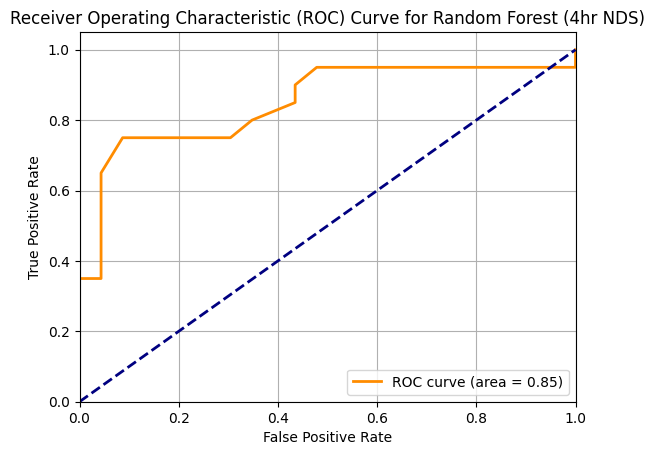

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming model is the trained Random Forest model for 4hr NDS classification
# Assuming y_test is the true labels for the test set
# Assuming y_test already contains numerical labels (0 for bad, 1 for good) based on previous steps.


# Get predicted probabilities for the positive class (class 1 - 'good')
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob) # Use y_test directly
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest (4hr NDS)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

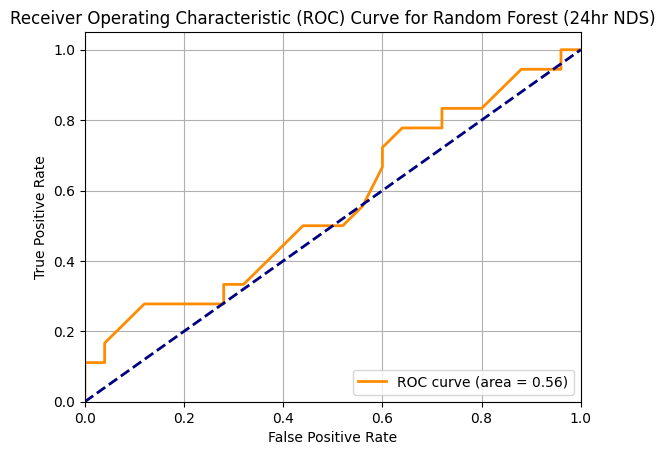

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming model_24hr is the trained Random Forest model for 24hr NDS classification
# Assuming X_test_24hr is the test set used for evaluation
# Assuming y_test_24hr is the true labels for the test set (string 'good'/'bad')

# Convert 'good'/'bad' labels in y_test_24hr to numerical (0 for bad, 1 for good)
label_to_numeric = {'bad': 0, 'good': 1}
y_test_24hr_numeric = [label_to_numeric[label] for label in y_test_24hr]


y_prob = model_24hr.predict_proba(X_test_24hr)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_24hr_numeric, y_prob) # Use y_test_24hr_numeric
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest (24hr NDS)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

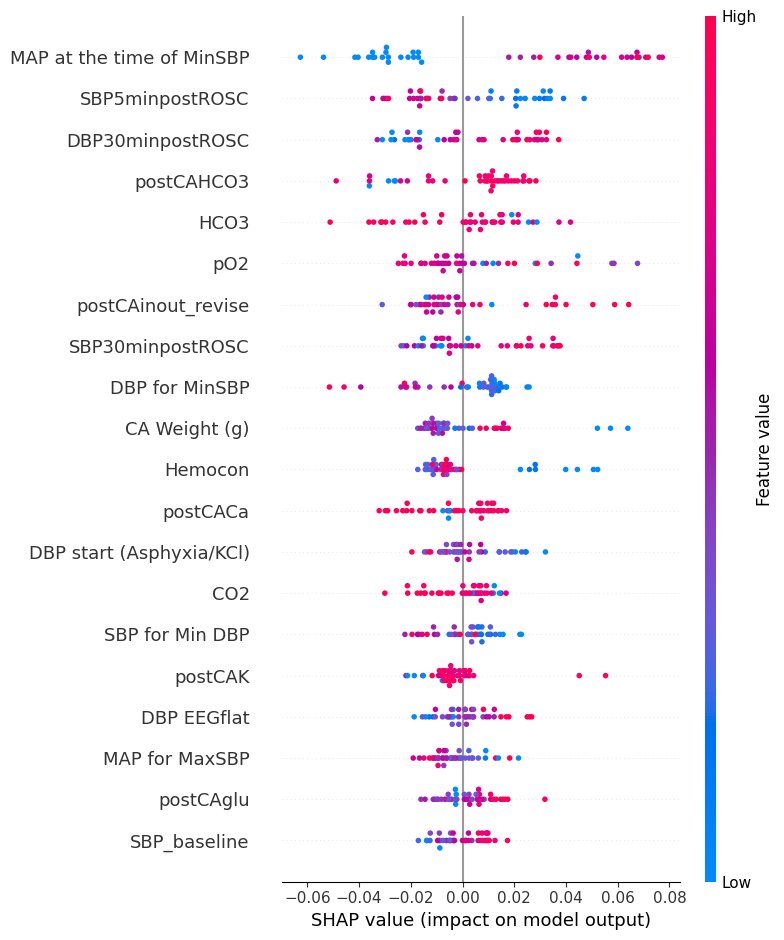

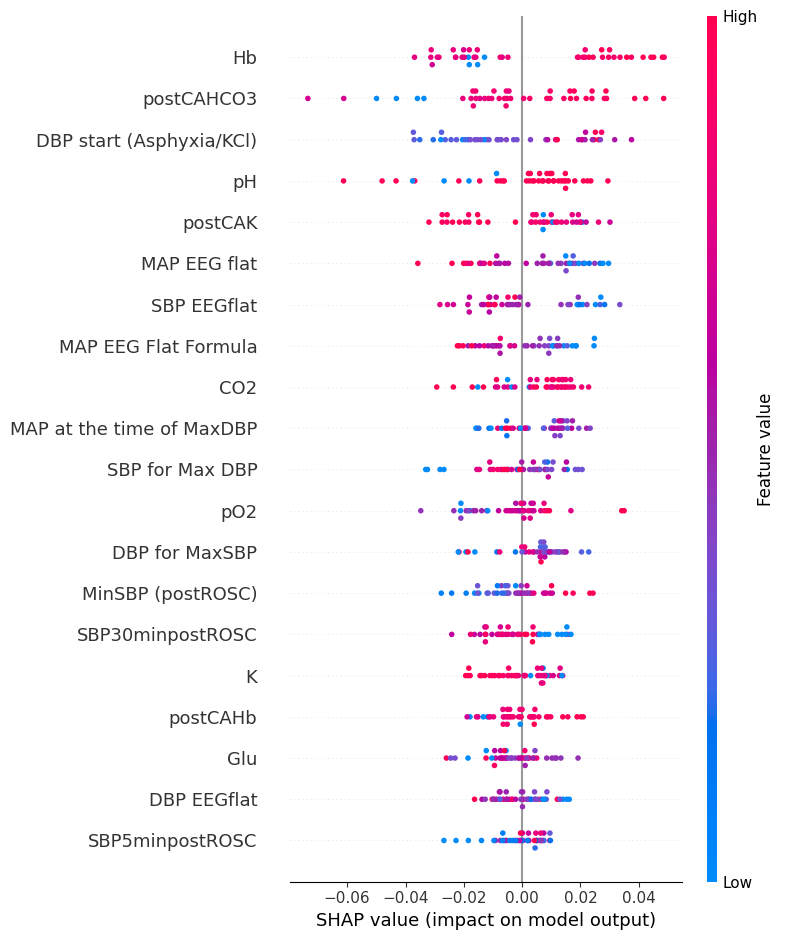

In [ ]:
import shap
import matplotlib.pyplot as plt

# -------------------------
# SHAP for 4hr NDS model
# -------------------------
explainer_4hr = shap.TreeExplainer(model)  # model is your 4hr RandomForest
shap_values_4hr = explainer_4hr.shap_values(X_test)

# Summary plot (global feature importance)

# Detailed beeswarm plot
shap.summary_plot(shap_values_4hr[:,:,1], X_test)

# -------------------------
# SHAP for 24hr NDS model
# -------------------------
explainer_24hr = shap.TreeExplainer(model_24hr)  # model_24hr is your 24hr RandomForest
shap_values_24hr = explainer_24hr.shap_values(X_test_24hr)

# Summary plot (global feature importance)

# Detailed beeswarm plot
shap.summary_plot(shap_values_24hr[:,:,1], X_test_24hr)

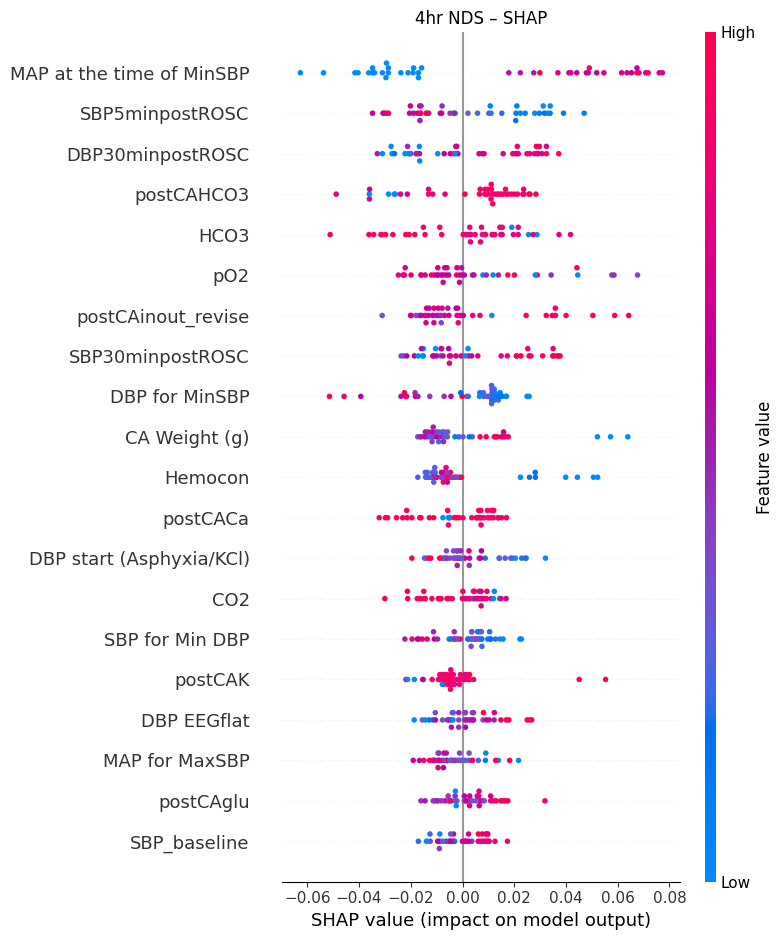

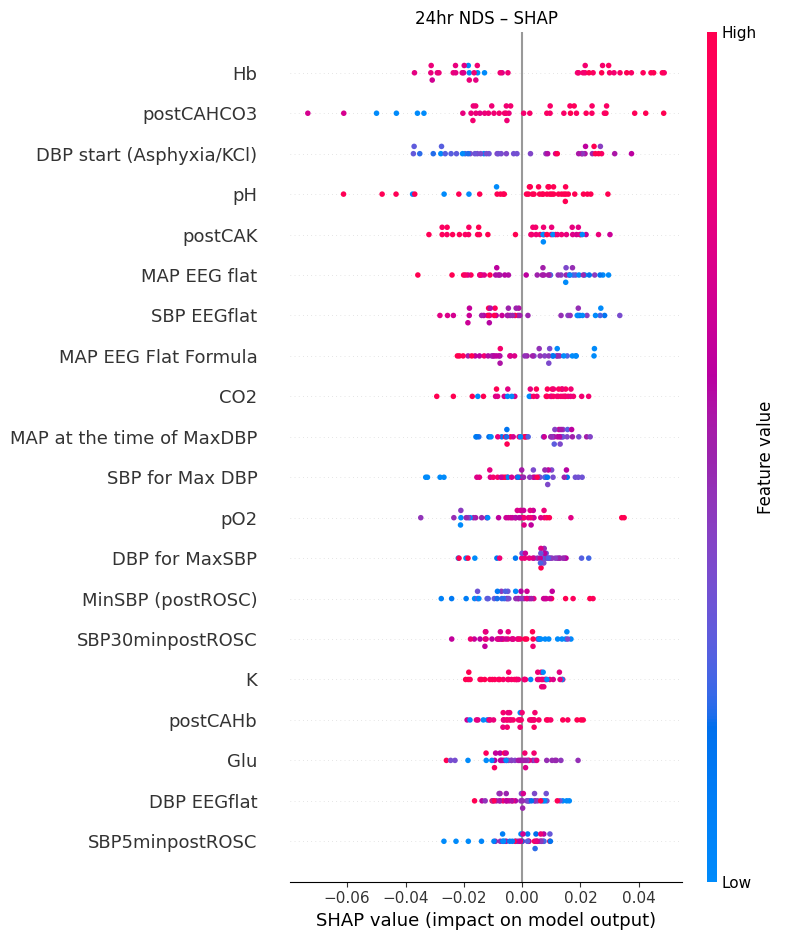

In [ ]:
# ----- 4hr NDS (beeswarm) -----
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values_4hr[:, :, 1], X_test, show=False)
plt.title("4hr NDS – SHAP")
plt.tight_layout()
plt.show()

# ----- 24hr NDS (beeswarm) -----
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values_24hr[:, :, 1], X_test_24hr, show=False)
plt.title("24hr NDS – SHAP")
plt.tight_layout()
plt.show()

In [ ]:
# pick the columns you want to show
selected_columns = [
       'MaxSBP (postROSC)', 'MinSBP (postROSC)', 'SBP for Min DBP',
       'SBP for Max DBP', 'SBP5minpostROSC', 'SBP30minpostROSC',

        'MAP for MaxSBP',
       'MAP at the time of MinSBP', 'MAP at the time of MaxDBP',
       'MAP at the time of MinDBP', 'DBP for MaxSBP', 'DBP for MinSBP', 'MaxDBP (postROSC)',
       'MinDBP (postROSC)', 'DBP5minpostROSC', 'DBP30minpostROSC']

# get their integer positions
cols_idx = [X_test_24hr.columns.get_loc(c) for c in selected_columns]

# slice SHAP values for class 1 and the selected columns
sv_selected = shap_values[:, cols_idx, 1]

# slice the data to the same column
X_selected = X_test_24hr[selected_columns]

# plot only those features
shap.summary_plot(sv_selected, X_selected, max_display=4)

NameError: name 'shap_values' is not defined

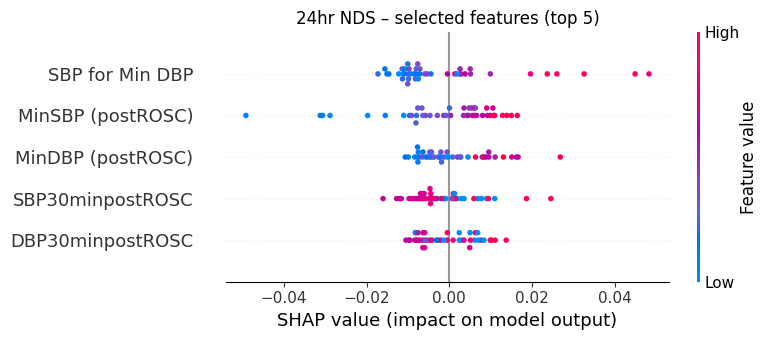

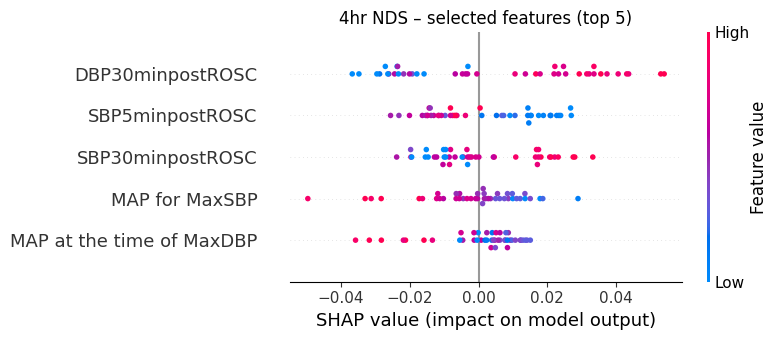

In [ ]:
import numpy as np

def plot_selected(model_name, shap_values, X, selected_cols, top_k=5, class_idx=1, plot_type="beeswarm"):
    use_cols = [c for c in selected_cols if c in getattr(X, "columns", selected_cols)]
    missing   = [c for c in selected_cols if c not in use_cols]
    if missing:
        print(f"{model_name}: missing columns:", missing)

    if hasattr(X, "columns"):  # DataFrame
        idx = [X.columns.get_loc(c) for c in use_cols]
        X_sel = X[use_cols]
    else:                       # NumPy
        idx = use_cols          # assume indices were passed
        X_sel = X[:, idx]

    # extract class matrix and slice columns
    sv_cls = shap_values[:, :, class_idx] if not isinstance(shap_values, list) else shap_values[class_idx]
    sv_sel = sv_cls[:, idx]

    # optional: SHAP already sorts, but if you want explicit top-k order:
    imp = np.abs(sv_sel).mean(axis=0)
    order = np.argsort(imp)[::-1][:top_k]
    sv_plot = sv_sel[:, order]
    X_plot  = X_sel.iloc[:, order] if hasattr(X_sel, "iloc") else X_sel[:, order]

    plt.figure(figsize=(8,6))
    shap.summary_plot(sv_plot, X_plot, max_display=top_k, plot_type=("bar" if plot_type=="bar" else None), show=False)
    plt.title(f"{model_name} – selected features (top {top_k})")
    plt.tight_layout()
    plt.show()

# Usage:
plot_selected("24hr NDS", shap_values_24hr, X_test_24hr, selected_columns, top_k=5)
plot_selected("4hr NDS",  shap_values_4hr,  X_test,      selected_columns, top_k=5)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df_no_reboa_numeric is already created and contains the features (X)
# And classification_4hr_nds is already created and contains the target (y)

# Define features (X) and target (y)
X = df_no_reboa_numeric
y = classification_4hr_nds

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the SVM model
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

print(f"Accuracy (SVM): {accuracy_svm}")
print("Classification Report (SVM):")
print(report_svm)

from sklearn.metrics import mean_absolute_error
# Assuming y_test and y_pred_svm are available from the previous SVM training for 4hr NDS

# Convert 'good'/'bad' labels to numerical values (e.g., 0 for bad, 1 for good)
label_to_numeric = {'bad': 0, 'good': 1}
y_test_numeric = [label_to_numeric[label] for label in y_test]
y_pred_svm_numeric = [label_to_numeric[label] for label in y_pred_svm]

# Calculate Mean Absolute Error for SVM
mae_svm = mean_absolute_error(y_test_numeric, y_pred_svm_numeric)

print(f"Mean Absolute Error (MAE) for SVM on 4hr NDS classification: {mae_svm}")

Accuracy (SVM): 0.7906976744186046
Classification Report (SVM):
              precision    recall  f1-score   support

         bad       0.78      0.82      0.80        22
        good       0.80      0.76      0.78        21

    accuracy                           0.79        43
   macro avg       0.79      0.79      0.79        43
weighted avg       0.79      0.79      0.79        43

Mean Absolute Error (MAE) for SVM on 4hr NDS classification: 0.20930232558139536


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df_no_reboa_numeric contains the features (X)
# Assuming classification_24hr_nds contains the target (y)

# Define features (X) and target (y) for 24hr NDS
X_24hr = df_no_reboa_numeric
y_24hr = classification_24hr_nds

# Split data into training and testing sets
X_train_24hr, X_test_24hr, y_train_24hr, y_test_24hr = train_test_split(X_24hr, y_24hr, test_size=0.2, random_state=42)

# Initialize and train the SVM model for 24hr NDS
svm_model_24hr = SVC(random_state=42)
svm_model_24hr.fit(X_train_24hr, y_train_24hr)

# Make predictions for 24hr NDS
y_pred_svm_24hr = svm_model_24hr.predict(X_test_24hr)

# Evaluate the model (optional, but good practice)
accuracy_svm_24hr = accuracy_score(y_test_24hr, y_pred_svm_24hr)
report_svm_24hr = classification_report(y_test_24hr, y_pred_svm_24hr)

print(f"Accuracy (SVM 24hr NDS): {accuracy_svm_24hr}")
print("Classification Report (SVM 24hr NDS):")
print(report_svm_24hr)


# Calculate Mean Absolute Error for SVM 24hr NDS
# Convert 'good'/'bad' labels to numerical values (e.g., 0 for bad, 1 for good)
label_to_numeric = {'bad': 0, 'good': 1}
y_test_24hr_numeric = [label_to_numeric[label] for label in y_test_24hr]
y_pred_svm_24hr_numeric = [label_to_numeric[label] for label in y_pred_svm_24hr]

mae_svm_24hr = mean_absolute_error(y_test_24hr_numeric, y_pred_svm_24hr_numeric)

print(f"Mean Absolute Error (MAE) for SVM 24hr NDS: {mae_svm_24hr}")

Accuracy (SVM 24hr NDS): 0.813953488372093
Classification Report (SVM 24hr NDS):
              precision    recall  f1-score   support

         bad       0.81      1.00      0.90        35
        good       0.00      0.00      0.00         8

    accuracy                           0.81        43
   macro avg       0.41      0.50      0.45        43
weighted avg       0.66      0.81      0.73        43

Mean Absolute Error (MAE) for SVM 24hr NDS: 0.18604651162790697


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_prob = svm_model_24hr.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob) # Use y_test directly
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM (24hr NDS)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

AttributeError: This 'SVC' has no attribute 'predict_proba'

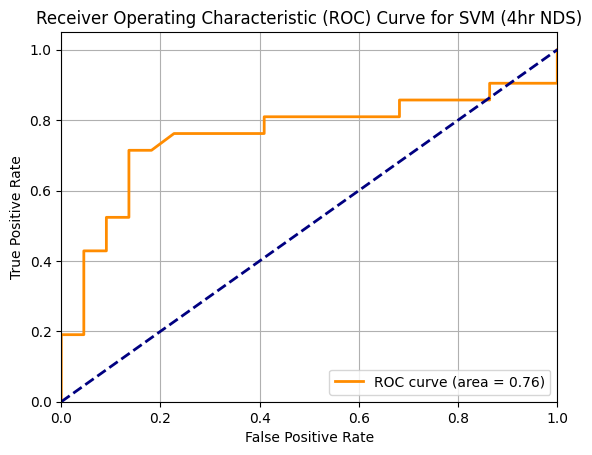

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df_no_reboa_numeric is already created and contains the features (X)
# Assuming classification_4hr_nds is already created and contains the target (y)

# Define features (X) and target (y)
X = df_no_reboa_numeric
y = classification_4hr_nds

# Convert 'good'/'bad' labels to numerical values (e.g., 0 for bad, 1 for good)
label_to_numeric = {'bad': 0, 'good': 1}
y_numeric = [label_to_numeric[label] for label in y]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.2, random_state=42)


# Initialize and train the SVM model with probability=True
svm_model_proba = SVC(random_state=42, probability=True)
svm_model_proba.fit(X_train, y_train)

# Get predicted probabilities for the positive class (class 1 - 'good')
y_prob_svm = svm_model_proba.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot the ROC curve
plt.figure()
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_svm)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM (4hr NDS)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

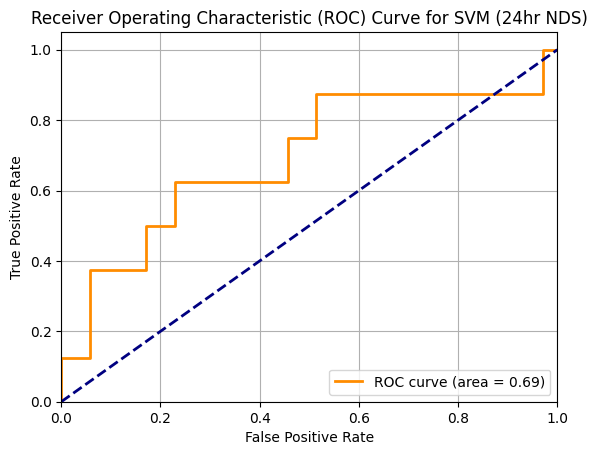

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

# Assuming df_no_reboa_numeric contains the features (X)
# Assuming classification_24hr_nds contains the target (y)

# Define features (X) and target (y) for 24hr NDS
X_24hr = df_no_reboa_numeric
y_24hr = classification_24hr_nds

# Convert 'good'/'bad' labels to numerical values (e.g., 0 for bad, 1 for good)
label_to_numeric = {'bad': 0, 'good': 1}
y_24hr_numeric = [label_to_numeric[label] for label in y_24hr]

# Split data into training and testing sets
X_train_24hr, X_test_24hr, y_train_24hr, y_test_24hr = train_test_split(X_24hr, y_24hr_numeric, test_size=0.2, random_state=42)


# Initialize and train the SVM model with probability=True for 24hr NDS
svm_model_24hr_proba = SVC(random_state=42, probability=True)
svm_model_24hr_proba.fit(X_train_24hr, y_train_24hr)

# Get predicted probabilities for the positive class (class 1 - 'good')
y_prob_svm_24hr = svm_model_24hr_proba.predict_proba(X_test_24hr)[:, 1]

# Calculate ROC curve and AUC
fpr_svm_24hr, tpr_svm_24hr, thresholds_svm_24hr = roc_curve(y_test_24hr, y_prob_svm_24hr)
roc_auc_svm_24hr = auc(fpr_svm_24hr, tpr_svm_24hr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr_svm_24hr, tpr_svm_24hr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_svm_24hr)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM (24hr NDS)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from xgboost import XGBClassifier
import pandas as pd
import numpy as np # Import numpy

# Define features (X) and target (y)
X = df_no_reboa_numeric # Using df_no_reboa_numeric as features
y = classification_4hr_nds

# Convert 'good'/'bad' labels to numerical values (e.g., 0 for bad, 1 for good)
label_to_numeric = {'bad': 0, 'good': 1}
# Convert to pandas Series with the same index as X
y_numeric = pd.Series([label_to_numeric[label] for label in y], index=X.index)


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_numeric, test_size=0.2, random_state=42)

# Convert X_train and X_test to NumPy arrays for better compatibility with XGBoost
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_np, y_train) # Use NumPy arrays for training

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_np) # Use NumPy array for prediction

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
report_xgb = classification_report(y_test, y_pred_xgb)

print(f"Accuracy (XGBoost 4hr NDS): {accuracy_xgb}")
print("Classification Report (XGBoost 4hr NDS):")
print(report_xgb)

# Calculate Mean Absolute Error for XGBoost 4hr NDS
# Convert 'good'/'bad' labels to numerical values (e.g., 0 for bad, 1 for good)
# label_to_numeric = {'bad': 0, 'good': 1} # Already defined
# y_test_numeric = [label_to_numeric[label] for label in y_test] # y_test is already numeric
# y_pred_xgb_numeric = [label_to_numeric[label] for label in y_pred_xgb] # y_pred_xgb is already numeric

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"Mean Absolute Error (MAE) for XGBoost 4hr NDS: {mae_xgb}")

Accuracy (XGBoost 4hr NDS): 0.813953488372093
Classification Report (XGBoost 4hr NDS):
              precision    recall  f1-score   support

           0       0.79      0.86      0.83        22
           1       0.84      0.76      0.80        21

    accuracy                           0.81        43
   macro avg       0.82      0.81      0.81        43
weighted avg       0.82      0.81      0.81        43

Mean Absolute Error (MAE) for XGBoost 4hr NDS: 0.18604651162790697


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error
from xgboost import XGBClassifier
import pandas as pd
import numpy as np # Import numpy

# Define features (X) and target (y) for 24hr NDS
X_24hr = df_no_reboa_numeric # Using df_no_reboa_numeric as features
y_24hr = classification_24hr_nds

# Convert 'good'/'bad' labels to numerical values (e.g., 0 for bad, 1 for good)
label_to_numeric = {'bad': 0, 'good': 1}
# Convert to pandas Series with the same index as X_24hr
y_24hr_numeric = pd.Series([label_to_numeric[label] for label in y_24hr], index=X_24hr.index)


# Split data into training and testing sets
X_train_24hr, X_test_24hr, y_train_24hr, y_test_24hr = train_test_split(X_24hr, y_24hr_numeric, test_size=0.2, random_state=42)

# Convert X_train_24hr and X_test_24hr to NumPy arrays for better compatibility with XGBoost
X_train_24hr_np = X_train_24hr.to_numpy()
X_test_24hr_np = X_test_24hr.to_numpy()


# Initialize and train the XGBoost model for 24hr NDS
xgb_model_24hr = XGBClassifier(random_state=42)
xgb_model_24hr.fit(X_train_24hr_np, y_train_24hr) # Use NumPy arrays for training

# Make predictions for 24hr NDS
y_pred_xgb_24hr = xgb_model_24hr.predict(X_test_24hr_np) # Use NumPy array for prediction

# Evaluate the model for 24hr NDS
accuracy_xgb_24hr = accuracy_score(y_test_24hr, y_pred_xgb_24hr)
report_xgb_24hr = classification_report(y_test_24hr, y_pred_xgb_24hr)

print(f"Accuracy (XGBoost 24hr NDS): {accuracy_xgb_24hr}")
print("Classification Report (XGBoost 24hr NDS):")
print(report_xgb_24hr)

# Calculate Mean Absolute Error for XGBoost 24hr NDS
# y_test_24hr is already numeric
# y_pred_xgb_24hr is already numeric

mae_xgb_24hr = mean_absolute_error(y_test_24hr, y_pred_xgb_24hr)

print(f"Mean Absolute Error (MAE) for XGBoost 24hr NDS: {mae_xgb_24hr}")

Accuracy (XGBoost 24hr NDS): 0.813953488372093
Classification Report (XGBoost 24hr NDS):
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        31
           1       0.67      0.67      0.67        12

    accuracy                           0.81        43
   macro avg       0.77      0.77      0.77        43
weighted avg       0.81      0.81      0.81        43

Mean Absolute Error (MAE) for XGBoost 24hr NDS: 0.18604651162790697


In [ ]:
import pandas as pd

# Assuming the following variables containing the metrics are available from previous steps:
# Random Forest 4hr: accuracy, report, mae
# Random Forest 24hr: accuracy_24hr, report_24hr, mae_24hr
# SVM 4hr: accuracy_svm, report_svm, mae_svm
# SVM 24hr: accuracy_svm_24hr, report_svm_24hr, mae_svm_24hr
# XGBoost 4hr: accuracy_xgb, report_xgb, mae_xgb
# XGBoost 24hr: accuracy_xgb_24hr, report_xgb_24hr, mae_xgb_24hr

# Extract F1-score values from classification reports
# Assuming 'good' class F1-score is the relevant one for 'good' outcome
f1_rf_4hr = float(report.split()[-2]) # F1-score for 'good' class in RF 4hr report
f1_rf_24hr = float(report_24hr.split()[-2]) # F1-score for 'good' class in RF 24hr report
f1_svm_4hr = float(report_svm.split()[-2]) # F1-score for 'good' class in SVM 4hr report
f1_svm_24hr = float(report_svm_24hr.split()[-2]) # F1-score for 'good' class in SVM 24hr report
f1_xgb_4hr = float(report_xgb.split()[-2]) # F1-score for '1' class in XGBoost 4hr report (assuming 1 is good)
f1_xgb_24hr = float(report_xgb_24hr.split()[-2]) # F1-score for '1' class in XGBoost 24hr report (assuming 1 is good)


# Create the data for the table
data = {'Model': ['Random Forest', 'SVM', 'XGBoost'],
        'MAE (4hr NDS)': [mae, mae_svm, mae_xgb],
        'MAE (24hr NDS)': [mae_24hr, mae_svm_24hr, mae_xgb_24hr],
        'F1-score (4hr NDS)': [f1_rf_4hr, f1_svm_4hr, f1_xgb_4hr],
        'F1-score (24hr NDS)': [f1_rf_24hr, f1_svm_24hr, f1_xgb_24hr]}

# Create the DataFrame
comparison_table = pd.DataFrame(data)

# Display the table
print("Model Comparison Table (with F1-scores):")
display(comparison_table)

Model Comparison Table (with F1-scores):


,Model,MAE (4hr NDS),MAE (24hr NDS),F1-score (4hr NDS),F1-score (24hr NDS)
0,Random Forest,0.255814,0.139535,0.74,0.82
1,SVM,0.325581,0.186047,0.66,0.73
2,XGBoost,0.186047,0.209302,0.81,0.79


In [ ]:
# get their integer positions
cols_idx = [X_test_4hr.columns.get_loc(c) for c in selected_columns]

# slice SHAP values for class 1 and the selected columns
sv_selected = shap_values[:, cols_idx, 1]

# slice the data to the same columns
X_selected = X_test_24hr[selected_columns]

# plot only those features
shap.summary_plot(sv_selected, X_selected, max_display=len(selected_columns))

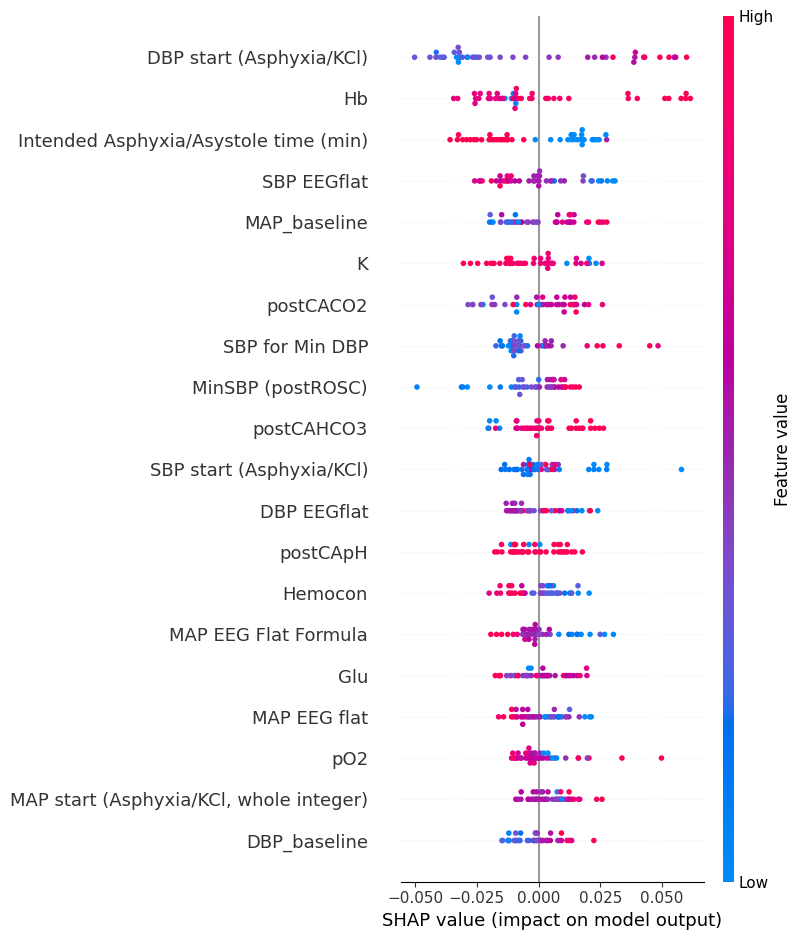

In [ ]:
import shap
import matplotlib.pyplot as plt

# Assuming xgb_model is the trained XGBoost model for 4hr NDS classification
# Assuming X_test is the test set used for evaluation

# Create a SHAP explainer
explainer = shap.Explainer(model_24hr)

# Calculate SHAP values for the test set
# Use the numpy array version of X_test if xgb_model was trained on numpy arrays
if isinstance(X_test_24hr, pd.DataFrame):
    shap_values = explainer(X_test_24hr.to_numpy())
else:
    shap_values = explainer(X_test_24hr)

# Generate the SHAP summary plot
selected_columns = []
shap.summary_plot(shap_values[:,:,1], X_test_24hr) # Use plot_type="bar" for feature importance



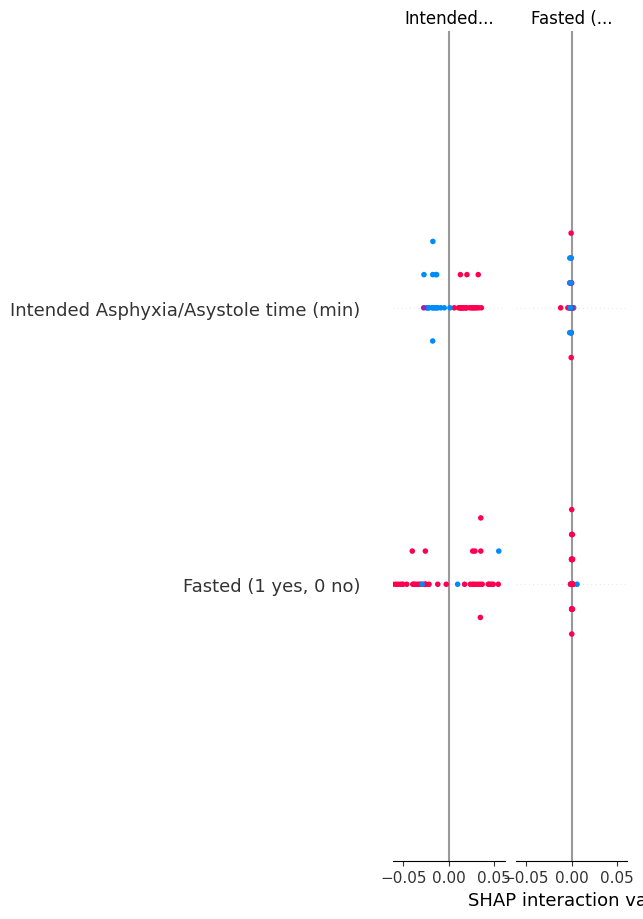

In [ ]:
# For a more detailed summary plot showing the distribution of SHAP values
shap.summary_plot(shap_values, X_test_24hr, max_display=10) # Limit to top 10 features